From the Evaluation of the Pre-trained models, two models one from Transfromer based and one CNN based came out best in their categories. There form The Two stage adaptation is performed for both. This set up forcuses on CNN based model. This is because each model family employess a different approach in achieveing the two stage adaptation.
For CNN Based model, DenseNet161 obtained consistent results across the two datasets it was evaluated on. to adapt it we perform a general adatation on the top three blocks, and in the second stage, adapt to darkskin by finetuning only the BN layers of the Top 3 blocks, this is because of the little data available for Darkskin.

In the cell below, it contains the environment set up includitning skleearn for learning metrics, and matplot lib for visualisation

In [1]:
import os, copy, time, json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In the Cell Below, the datafoler/path is defined, also the output directory is set. The trianing configuration used in the evaluation is maintained, however, the epochs are set foe each stage. The learning rate is also set first for training the classifiere head and then for finetuning the top blocks of the model

In [2]:
# ===== EDIT THIS PATH =====
#DATA_ROOT = "/kaggle/input/fitzpatrickfull/Fitzpatrick17k" 
#DATA_ROOT = "/kaggle/input/passion2024/PASSION2024"
DATA_ROOT = "/kaggle/input/fitzpatrick17k456/Fitzpatrick17k_456"

OUT_DIR = "/kaggle/working/DA_ST1"
os.makedirs(OUT_DIR, exist_ok=True)

# Training config
SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 2
VAL_SPLIT = 0.2
IMG_SIZE = 224

EPOCHS_HEAD = 10        # phase 1: head-only
EPOCHS_TOP3 = 30       # phase 2: top-1 block + head

LR_HEAD = 1e-3
LR_TOP3 = 5e-4
WEIGHT_DECAY = 1e-4


In the cell below, Data transfromation and Dataloading is implemented. The transforms help in simple data augmentation and converting the images to tensors which can be ingested during the trainings.

In [3]:
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def get_transforms(img_size=224):
    train_t = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    val_t = transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return train_t, val_t

def load_imagefolder_split(root, val_split=0.2, batch_size=32, num_workers=2, img_size=224, seed=42):
    train_t, val_t = get_transforms(img_size)
    full = datasets.ImageFolder(root=root, transform=train_t)

    n_total = len(full)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val

    train_ds, val_ds = random_split(
        full, [n_train, n_val],
        generator=torch.Generator().manual_seed(seed)
    )

    # set val transform
    val_ds.dataset = copy.copy(val_ds.dataset)
    val_ds.dataset.transform = val_t

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, full.class_to_idx

train_loader, val_loader, class_to_idx = load_imagefolder_split(
    DATA_ROOT, VAL_SPLIT, BATCH_SIZE, NUM_WORKERS, IMG_SIZE, SEED
)

num_classes = len(class_to_idx)
print("num_classes:", num_classes)
print("class_to_idx:", class_to_idx)


num_classes: 107
class_to_idx: {'acanthosis nigricans': 0, 'acne': 1, 'acne vulgaris': 2, 'acquired autoimmune bullous diseaseherpes gestationis': 3, 'acrodermatitis enteropathica': 4, 'actinic keratosis': 5, 'allergic contact dermatitis': 6, 'aplasia cutis': 7, 'basal cell carcinoma': 8, 'becker nevus': 9, 'behcets disease': 10, 'calcinosis cutis': 11, 'cheilitis': 12, 'congenital nevus': 13, 'dariers disease': 14, 'dermatofibroma': 15, 'dermatomyositis': 16, 'drug eruption': 17, 'drug induced pigmentary changes': 18, 'dyshidrotic eczema': 19, 'eczema': 20, 'ehlers danlos syndrome': 21, 'epidermal nevus': 22, 'epidermolysis bullosa': 23, 'erythema annulare centrifigum': 24, 'erythema elevatum diutinum': 25, 'erythema multiforme': 26, 'erythema nodosum': 27, 'factitial dermatitis': 28, 'fixed eruptions': 29, 'folliculitis': 30, 'fordyce spots': 31, 'granuloma annulare': 32, 'granuloma pyogenic': 33, 'hailey hailey disease': 34, 'halo nevus': 35, 'hidradenitis': 36, 'ichthyosis vulgaris

Below, the Setup/building of DenseNet161 is done. First the pretained mdoel is loaded and a new classifier head attached to match the domain it s being adapted to. Then the top three blocks ie Blocks 4, Transition3 and Block 3 are set for finetuning.

In [16]:
def build_densenet161(num_classes: int) -> nn.Module:
    m = models.densenet161(weights=models.DenseNet161_Weights.DEFAULT)
    # Replacing classifier to match dataset classes
    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    return m

def freeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_module(module: nn.Module):
    for p in module.parameters():
        p.requires_grad = True

def get_top_blocks_densenet(model: nn.Module):
    """
    DenseNet161 features:
      conv0, norm0, relu0, pool0,
      denseblock1, transition1,
      denseblock2, transition2,
      denseblock3, transition3,
      denseblock4, norm5

    We define the 'top block' as ONLY:
      - denseblock4 (deepest semantic block)
    """
    return [model.features.denseblock4]


def set_trainable_head_only(model: nn.Module):
    freeze_all(model)
    unfreeze_module(model.classifier)  # train only classifier head

def set_trainable_block4_and_head(model: nn.Module):
    # Freeze everything
    for p in model.parameters():
        p.requires_grad = False

    # Unfreeze classifier head
    for p in model. classifier.parameters():
        p.requires_grad = True

    # Unfreeze DenseBlock4 only
    for p in model.features.denseblock4.parameters():
        p.requires_grad = True

def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Ready.")


Ready.


The triaining and evaluation is done, The evaluation takes into account the validation accuracy, the weighted/Macro Fi but the best model is saved based on the Weighted F1 Scaore

In [13]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    ce = nn.CrossEntropyLoss()
    running_loss = 0.0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = ce(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

    return running_loss / max(1, n)

@torch.no_grad()
def eval_metrics(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss()

    all_y, all_p = [], []
    running_loss = 0.0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = ce(logits, y)
        preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

        all_y.append(y.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    val_loss = running_loss / max(1, n)
    val_acc = accuracy_score(y_true, y_pred)
    w_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    m_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return val_loss, val_acc, w_f1, m_f1

def fit_and_save_best(model, phase_name, train_loader, val_loader, epochs, lr, weight_decay, out_dir, device):
    best_wf1 = -1.0
    patience = 5
    patience_counter = 0

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    history = []
    best_wf1 = -1.0

    best_ckpt_path = os.path.join(out_dir, f"densenet161_{phase_name}_best.pt")
    hist_csv_path  = os.path.join(out_dir, f"densenet161_{phase_name}_history.csv")

    for ep in range(1, epochs + 1):
        t0 = time.time()

        tr_loss = train_one_epoch(model, train_loader, optimizer, device)
        va_loss, va_acc, w_f1, m_f1 = eval_metrics(model, val_loader, device)

        row = {
            "epoch": ep,
            "train_loss": tr_loss,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "weighted_f1": w_f1,
            "macro_f1": m_f1,
            "seconds": time.time() - t0,
            "trainable_params": count_trainable_params(model),
        }
        history.append(row)

        print(
            f"[{phase_name}] ep {ep:03d}/{epochs} | "
            f"tr_loss={tr_loss:.4f} | va_acc={va_acc:.4f} | wF1={w_f1:.4f} | mF1={m_f1:.4f} | "
            f"trainable={row['trainable_params']:,}"
        )
        # Save BEST by weighted F1 + early stopping
        if w_f1 > best_wf1:
            best_wf1 = w_f1
            patience_counter = 0  # reset patience
        
            torch.save({
                "phase": phase_name,
                "best_epoch": ep,
                "best_weighted_f1": best_wf1,
                "best_val_acc": va_acc,
                "best_macro_f1": m_f1,
                "class_to_idx": class_to_idx,
                "trainable_params": count_trainable_params(model),
                "state_dict": copy.deepcopy(model.state_dict()),
            }, best_ckpt_path)
        
            print(f"New best wF1={best_wf1:.4f} at epoch {ep}")
        
        else:
            patience_counter += 1
            print(f"No improvement in wF1 ({patience_counter}/{patience})")
        
        # ---- EARLY STOP ----
        if patience_counter >= patience:
            print(
                f"\n Early stopping triggered at epoch {ep} "
                f"(best wF1={best_wf1:.4f})"
            )
            break


        

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(hist_csv_path, index=False)

    print(f"\n[{phase_name}] BEST weighted F1 = {best_wf1:.4f}")
    print("Saved best checkpoint:", best_ckpt_path)
    print("Saved history CSV:", hist_csv_path)

    return best_ckpt_path, hist_df


Ploting the training progress for visualization

In [14]:
def plot_history(hist_df, title_prefix=""):
    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy")
    plt.title(f"{title_prefix} Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(hist_df["epoch"], hist_df["weighted_f1"], label="weighted_f1")
    plt.plot(hist_df["epoch"], hist_df["macro_f1"], label="macro_f1")
    plt.xlabel("epoch"); plt.ylabel("F1 score")
    plt.title(f"{title_prefix} F1 Scores")
    plt.legend()
    plt.show()


Phase one of the Set up, Trining the classifier head and saving the best.

Phase1 trainable params: 236363
[head_only] ep 001/10 | tr_loss=4.0903 | va_acc=0.1941 | wF1=0.1542 | mF1=0.0781 | trainable=236,363
New best wF1=0.1542 at epoch 1
[head_only] ep 002/10 | tr_loss=3.0912 | va_acc=0.2739 | wF1=0.2477 | mF1=0.1805 | trainable=236,363
New best wF1=0.2477 at epoch 2
[head_only] ep 003/10 | tr_loss=2.5682 | va_acc=0.2949 | wF1=0.2746 | mF1=0.2204 | trainable=236,363
New best wF1=0.2746 at epoch 3
[head_only] ep 004/10 | tr_loss=2.2154 | va_acc=0.3652 | wF1=0.3394 | mF1=0.2804 | trainable=236,363
New best wF1=0.3394 at epoch 4
[head_only] ep 005/10 | tr_loss=1.9604 | va_acc=0.3767 | wF1=0.3597 | mF1=0.2857 | trainable=236,363
New best wF1=0.3597 at epoch 5
[head_only] ep 006/10 | tr_loss=1.7580 | va_acc=0.4050 | wF1=0.3872 | mF1=0.3245 | trainable=236,363
New best wF1=0.3872 at epoch 6
[head_only] ep 007/10 | tr_loss=1.5994 | va_acc=0.3924 | wF1=0.3742 | mF1=0.3062 | trainable=236,363
No improvement in wF1 (1/5)
[head_only] ep 008/10 | tr_loss=1.4616 | va_acc

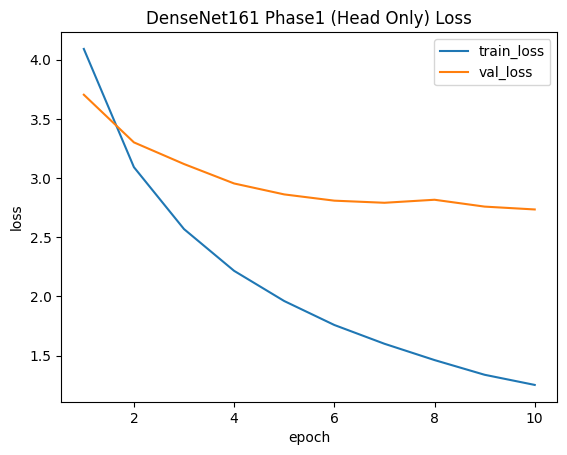

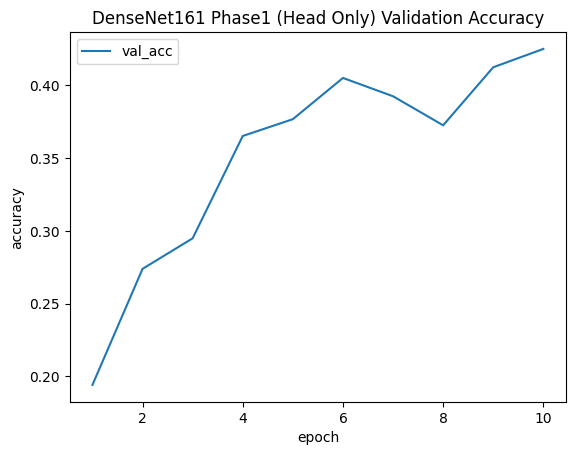

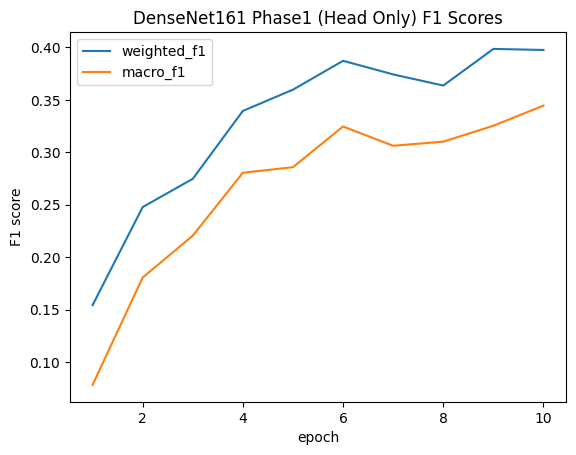

In [17]:
model = build_densenet161(num_classes).to(device)

set_trainable_head_only(model)
print("Phase1 trainable params:", count_trainable_params(model))

ckpt_head_best, hist_head = fit_and_save_best(
    model=model,
    phase_name="head_only",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_HEAD,
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY,
    out_dir=OUT_DIR,
    device=device
)

plot_history(hist_head, title_prefix="DenseNet161 Phase1 (Head Only)")


Stage 1: Finetuning the top blocks and saving the best

In [18]:
# 1) Confirm trainable params are only in denseblock4 + classifier
for name, p in model2.named_parameters():
    if p.requires_grad:
        if not (name.startswith("features.denseblock4.") or name.startswith("classifier.")):
            print(" Unexpected trainable param:", name)
            break
else:
    print(" Only denseblock4 + classifier are trainable.")

# 2) Count trainable tensors (should not be huge)
trainable_tensors = [n for n, p in model2.named_parameters() if p.requires_grad]
print("Trainable tensors:", len(trainable_tensors))
print("First few:", trainable_tensors[:10])


NameError: name 'model2' is not defined

Phase2 trainable params: 9723083
[top3_blocks] ep 001/30 | tr_loss=1.6303 | va_acc=0.4638 | wF1=0.4498 | mF1=0.3769 | trainable=9,723,083
New best wF1=0.4498 at epoch 1
[top3_blocks] ep 002/30 | tr_loss=0.6246 | va_acc=0.5068 | wF1=0.4964 | mF1=0.4172 | trainable=9,723,083
New best wF1=0.4964 at epoch 2
[top3_blocks] ep 003/30 | tr_loss=0.3070 | va_acc=0.5247 | wF1=0.5121 | mF1=0.4327 | trainable=9,723,083
New best wF1=0.5121 at epoch 3
[top3_blocks] ep 004/30 | tr_loss=0.1628 | va_acc=0.5163 | wF1=0.5100 | mF1=0.4409 | trainable=9,723,083
No improvement in wF1 (1/5)
[top3_blocks] ep 005/30 | tr_loss=0.1337 | va_acc=0.5373 | wF1=0.5223 | mF1=0.4360 | trainable=9,723,083
New best wF1=0.5223 at epoch 5
[top3_blocks] ep 006/30 | tr_loss=0.1181 | va_acc=0.5435 | wF1=0.5371 | mF1=0.4653 | trainable=9,723,083
New best wF1=0.5371 at epoch 6
[top3_blocks] ep 007/30 | tr_loss=0.0553 | va_acc=0.5435 | wF1=0.5312 | mF1=0.4505 | trainable=9,723,083
No improvement in wF1 (1/5)
[top3_blocks] ep 008/

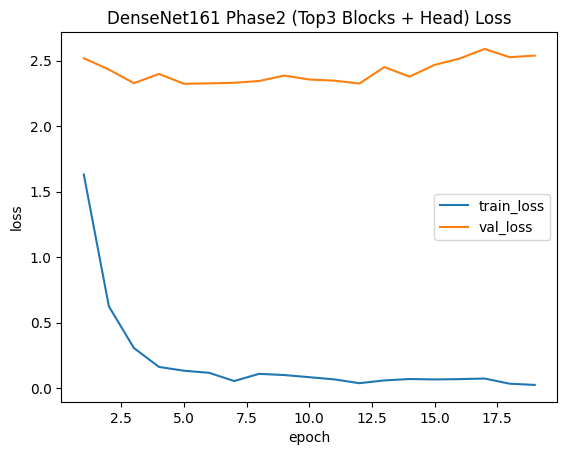

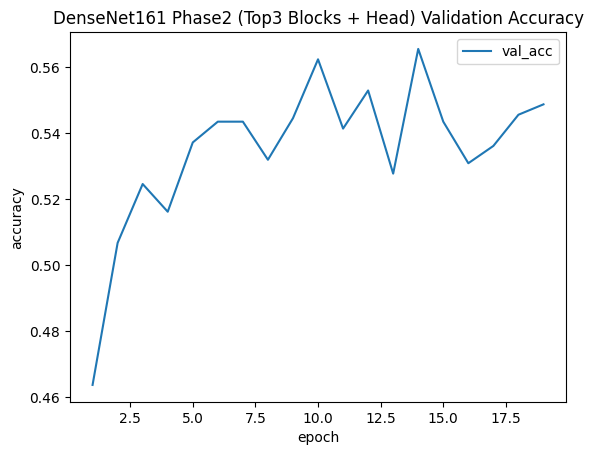

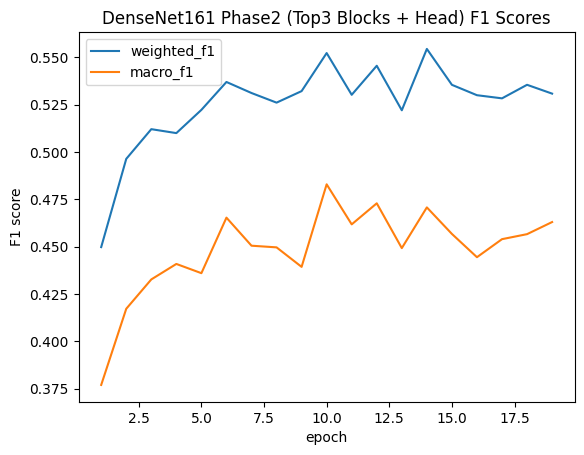

In [19]:
# Load best head-only checkpoint
model2 = build_densenet161(num_classes).to(device)
ckpt = torch.load(ckpt_head_best, map_location=device)
model2.load_state_dict(ckpt["state_dict"])

#set_trainable_top3_and_head(model2)
set_trainable_block4_and_head(model2)
print("Phase2 trainable params:", count_trainable_params(model2))

ckpt_top3_best, hist_top3 = fit_and_save_best(
    model=model2,
    phase_name="top3_blocks",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_TOP3,
    lr=LR_TOP3,
    weight_decay=WEIGHT_DECAY,
    out_dir=OUT_DIR,
    device=device
)

plot_history(hist_top3, title_prefix="DenseNet161 Phase2 (Top3 Blocks + Head)")


The cell below shows the best model sumary

In [ ]:
best_head = torch.load(ckpt_head_best, map_location="cpu")["best_weighted_f1"]
best_top3 = torch.load(ckpt_top3_best, map_location="cpu")["best_weighted_f1"]

print("Best weighted F1 (Phase1 head-only):", best_head)
print("Best weighted F1 (Phase2 top3 blocks):", best_top3)

print("\nSaved files are in:", OUT_DIR)
print(" -", ckpt_head_best)
print(" -", ckpt_top3_best)


To kick start stage Two, The new dataset focusing on darks skin tones is being loaded, the best saved =, adapted model is also being loaded. A key thing to note in this is that the classes in the previous stage are 114 but this satge has only 107, there fore we have to build DenseNet161 afresha and reload the saved weights.